# DSCI 503 - Homework 05
### Ben Miller

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Problem 1: Working with 2D Arrays

In [2]:
np.random.seed(1)
Z = np.random.uniform(low=0, high=10, size=(5, 8))
Z = np.round(Z, 2)
print(Z)

[[4.17 7.2  0.   3.02 1.47 0.92 1.86 3.46]
 [3.97 5.39 4.19 6.85 2.04 8.78 0.27 6.7 ]
 [4.17 5.59 1.4  1.98 8.01 9.68 3.13 6.92]
 [8.76 8.95 0.85 0.39 1.7  8.78 0.98 4.21]
 [9.58 5.33 6.92 3.16 6.87 8.35 0.18 7.5 ]]


In [3]:
print("Row 3:   ", Z[2, :]) # Print the 3rd row
print("Column 6:", Z[:, 5]) # Print the 6th column

Row 3:    [4.17 5.59 1.4  1.98 8.01 9.68 3.13 6.92]
Column 6: [0.92 8.78 9.68 8.78 8.35]


In [4]:
print("Row Sums:   ", np.sum(Z, axis=1)) # Print the sum of each row
print("Column Sums:", np.sum(Z, axis=0)) # Print the sum of each column
print("Array Sum:  ", np.sum(Z))         # Print the sum of the entire array

Row Sums:    [22.1  38.19 40.88 34.62 47.89]
Column Sums: [30.65 32.46 13.36 15.4  20.09 36.51  6.42 28.79]
Array Sum:   183.68


## Problem 2: Reshaping and Stacking Arrays

In [5]:
np.random.seed(167)
x1 = np.random.normal(loc=50, scale=10, size=1000)
x2 = np.random.normal(loc=20, scale=5, size=1000)
x3 = np.random.normal(loc=100, scale=30, size=1000)
x4 = np.random.normal(loc=10, scale=2, size=1000)

col_x1 = x1.reshape(1000, 1)
col_x2 = x2.reshape(1000, 1)
col_x3 = x3.reshape(1000, 1)
col_x4 = x4.reshape(1000, 1)

X = np.hstack([col_x1, col_x2, col_x3, col_x4]) # create a 1000x4 array
X = np.round(X, 2)
print(X.shape)

(1000, 4)


In [6]:
print(X[:6, :]) # print the first 6 rows of the array

[[ 37.08  16.71 138.06   8.89]
 [ 41.32  19.91  99.61   9.86]
 [ 63.15  14.43  70.08  11.6 ]
 [ 50.03  12.71  95.05   8.47]
 [ 55.05  24.4   62.16   9.49]
 [ 59.24  25.68  64.57  12.84]]


## Problem 3: Standardization

In [7]:
col_means = np.mean(X, axis=0)
col_stds = np.std(X, axis=0)

print("Column means:               ", np.round(col_means, 2))
print("Column standard deviations: ", np.round(col_stds, 2))

Column means:                [50.21 19.86 99.84 10.06]
Column standard deviations:  [ 9.69  5.08 30.88  2.03]


In [8]:
# standardize the array by subtracting the mean and dividing by the standard deviation
W = (X - col_means) / col_stds
W_col_means = np.mean(W, axis=0)
W_col_stds = np.std(W, axis=0)

print("Column means:               ", np.round(W_col_means, 2))
print("Column standard deviations: ", np.round(W_col_stds, 2))

Column means:                [ 0. -0. -0. -0.]
Column standard deviations:  [1. 1. 1. 1.]


## Problem 4: Load Auto MPG Dataset

In [9]:
auto = pd.read_csv('auto_mpg.txt', sep='\t')
auto.head(10)

,mpg,cyl,wt,region,model
0,27.2,4,3190,eur,peugeot 504
1,32.8,4,1985,asia,mazda glc deluxe
2,18.1,6,3410,usa,amc concord d/l
3,17.5,8,4080,usa,dodge magnum xe
4,25.4,5,3530,eur,mercedes benz 300d
5,31.0,4,1773,asia,toyota corolla 1200
6,27.4,4,2670,usa,amc spirit dl
7,39.1,4,1755,asia,toyota starlet
8,34.3,4,2188,eur,audi 4000
9,30.0,4,2155,usa,buick opel isuzu deluxe


In [10]:
print(auto.shape)

(398, 5)


In [11]:
# find the mean of the numeric columns
column_means = auto.loc[:, ['mpg', 'cyl', 'wt']].mean()
print(column_means)

mpg      23.514573
cyl       5.454774
wt     2970.424623
dtype: float64


## Problem 5: Regional Counts and Means

In [12]:
regions = np.unique(auto.region.tolist())
print(regions)

['asia' 'eur' 'usa']


In [13]:
asia_auto = auto[auto.region == 'asia']
europe_auto = auto[auto.region == 'eur']
usa_auto = auto[auto.region == 'usa']

print("Number of cars manufactured in Asia:  ", asia_auto.shape[0])
print("Number of cars manufactured in Europe:", europe_auto.shape[0])
print("Number of cars manufactured in US:    ", usa_auto.shape[0])

Number of cars manufactured in Asia:   79
Number of cars manufactured in Europe: 70
Number of cars manufactured in US:     249


In [14]:
asia_means = asia_auto.loc[:, ['mpg', 'cyl', 'wt']].mean()
europe_means = europe_auto.loc[:, ['mpg', 'cyl', 'wt']].mean()
usa_means = usa_auto.loc[:, ['mpg', 'cyl', 'wt']].mean()

mean_df = pd.DataFrame([asia_means, europe_means, usa_means])
mean_df.set_index(regions, inplace=True)
mean_df

,mpg,cyl,wt
asia,30.450633,4.101266,2221.227848
eur,27.891429,4.157143,2423.300000
usa,20.083534,6.248996,3361.931727


## Problem 6: Average Weight and MPG by Region

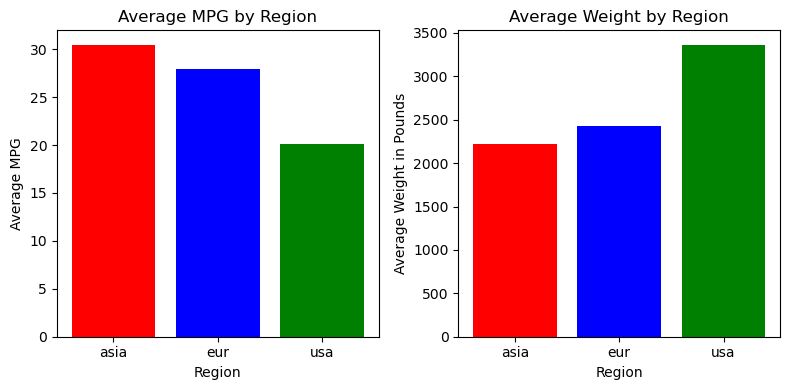

In [15]:
colors1 = ['red', 'blue', 'green']

# create side-by-side sub plots
fig, (bar_mpg, bar_wt) = plt.subplots(1, 2, figsize=(8, 4))

# create the left bar plot for Miles Per Gallon
bar_mpg.bar(mean_df.index, mean_df['mpg'], color=colors1)
bar_mpg.set_title('Average MPG by Region')
bar_mpg.set_ylabel('Average MPG')
bar_mpg.set_xlabel('Region')

# create the right bar plot for Weight
bar_wt.bar(mean_df.index, mean_df['wt'], color=colors1)
bar_wt.set_title('Average Weight by Region')
bar_wt.set_ylabel('Average Weight in Pounds')
bar_wt.set_xlabel('Region')

plt.tight_layout()
plt.show()

## Problem 7: Relationship between Weight and Miles Per Gallon

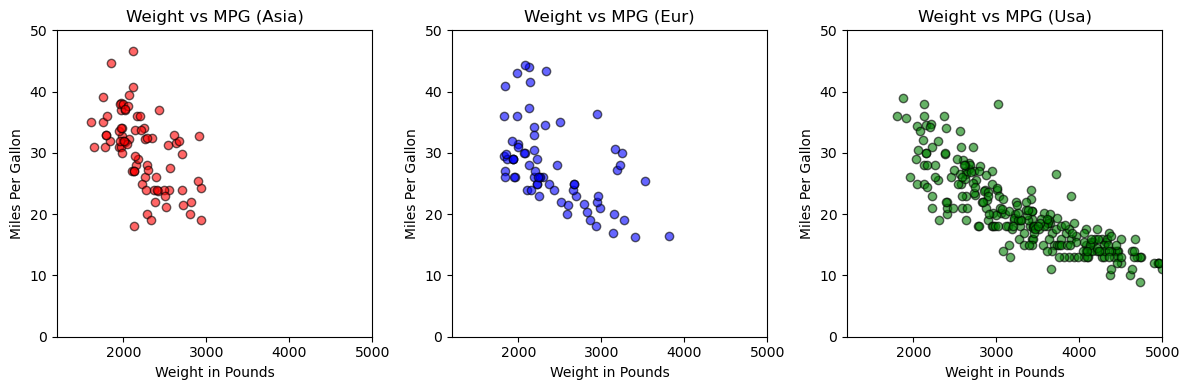

In [16]:
plt.figure(figsize=[12, 4])

for i in range(len(regions)):
    plt.subplot(1, 3, i + 1)

    region_mask = auto.loc[:, 'region'] == regions[i]
    wt_by_region = auto.loc[region_mask, 'wt']
    mpg_by_region = auto.loc[region_mask, 'mpg']

    plt.scatter(wt_by_region, mpg_by_region, alpha=0.6, color=colors1[i], edgecolor="black")
    plt.xlim([1200, 5000])
    plt.ylim([0, 50])
    plt.xlabel('Weight in Pounds')
    plt.ylabel('Miles Per Gallon')
    plt.title(f'Weight vs MPG ({regions[i].title()})')

plt.tight_layout()
plt.show()

## Problem 8: Cylinder Distribution by Region

In [17]:
cyl_values = np.unique(auto.cyl.tolist())
print(cyl_values)

[3 4 5 6 8]


In [18]:
cyl_counts_by_region = pd.crosstab(auto['cyl'], auto['region'])
cyl_counts_by_region

region,asia,eur,usa
cyl,,,
3,4,0,0
4,69,63,72
5,0,3,0
6,6,4,74
8,0,0,103


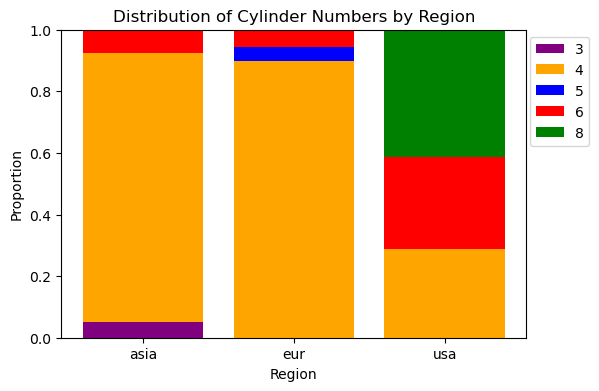

In [19]:
cyl_props_by_region = cyl_counts_by_region / cyl_counts_by_region.sum(axis=0)
bar_bottoms = np.cumsum(cyl_props_by_region) - cyl_props_by_region

colors2 = ['purple', 'orange', 'blue', 'red', 'green']

plt.figure(figsize=[6, 4])

for i in range(len(cyl_props_by_region)):
    plt.bar(cyl_props_by_region.columns, cyl_props_by_region.iloc[i, :], 
            bottom=bar_bottoms.iloc[i, :], color=colors2[i], label=cyl_props_by_region.index[i])

plt.xlabel('Region')
plt.ylabel('Proportion')    
plt.title('Distribution of Cylinder Numbers by Region')
plt.legend(bbox_to_anchor=(1.15,1))
plt.show()